In [16]:
import numpy as np
from pymdp.agent import Agent

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io
import imageio
from itertools import product
import random
from IPython.display import Image, display

# reproducibility
random.seed(42)
np.random.seed(1)

In [17]:
# BLOCK 1: Build arena mask + mappings (modular arena)
# You can change rows, cols, and corridor params below to create different arenas.

def make_two_rooms_with_corridor(rows=3, left_cols=2, corridor_cols=3, right_cols=2,
                                 corridor_rows=(1),  # tuple/list of row indices that ARE passable in corridor
                                 prefer_total_cols=None):
    """
    Construct a boolean mask for two square rooms (left, right) connected by a corridor.
    Returns mask (rows x total_cols) with True for passable cells and False for blocked.
    corridor_rows: which rows (0-indexed) in the corridor region are allowed to be passable.
                   e.g., (1,2) for two middle rows in a 4-row grid.
    prefer_total_cols: if you need a target total width (e.g. 10), you can supply it and
                       function will try to center corridor; if None, uses left+corridor+right.
    """
    # compute total_cols
    default_total = left_cols + corridor_cols + right_cols
    if prefer_total_cols is None:
        total_cols = default_total
    else:
        total_cols = prefer_total_cols
        # If prefer_total_cols differs from default, we will embed the three regions appropriately
        # We'll place left at col 0, corridor after left, and right at the end so overall fits.
    mask = np.zeros((rows, total_cols), dtype=bool)

    # left room: columns 0 .. left_cols-1 (all rows)
    left_start = 0
    left_end = left_start + left_cols  # exclusive
    mask[:, left_start:left_end] = True

    # corridor: place immediately after left
    corridor_start = left_end
    corridor_end = corridor_start + corridor_cols
    if corridor_end > total_cols:
        raise ValueError("Corridor doesn't fit in prefer_total_cols; increase total width or reduce corridor width.")
    # corridor rows: only allow rows in corridor_rows list (e.g., middle rows)
    for r in corridor_rows:
        mask[r, corridor_start:corridor_end] = True

    # right room: place at the end to make total width sensible
    right_end = total_cols
    right_start = right_end - right_cols
    mask[:, right_start:right_end] = True

    return mask, {"left": (slice(None), slice(left_start, left_end)),
                  "corridor": (slice(None), slice(corridor_start, corridor_end)),
                  "right": (slice(None), slice(right_start, right_end))}

# Example 1: two 4x4 rooms connected by 2x3 corridor => total cols = 4 + 3 + 4 = 11
rows = 2
left_cols = 1
corridor_cols = 2   # corridor width
right_cols = 1
corridor_rows = (1,)  # allow rows 1 and 2 (middle two rows), top(0) and bottom(3) are blocked in corridor
mask, regions = make_two_rooms_with_corridor(rows=rows, left_cols=left_cols,
                                             corridor_cols=corridor_cols, right_cols=right_cols,
                                             corridor_rows=corridor_rows, prefer_total_cols=None)

# If you *really* want a 4x10 grid, you can call with prefer_total_cols=10, but ensure corridor fits:
# mask, regions = make_two_rooms_with_corridor(rows=4, left_cols=4, corridor_cols=2, right_cols=4,
#                                              corridor_rows=(1,2), prefer_total_cols=10)

print("Arena mask shape:", mask.shape)
print("Passable cells count:", mask.sum())


Arena mask shape: (2, 4)
Passable cells count: 6


In [18]:
# BLOCK 2: Compact mapping from (r,c) -> state index and back for only passable cells


rows, cols = mask.shape
# create list of valid (r,c) and mapping arrays
valid_rc = [(r, c) for r in range(rows) for c in range(cols) if mask[r, c]]
n_states = len(valid_rc)


# observation modalities -> threat intensity/dist, shelter, agent location
n_threat_obs = 4                         # intensities 0..3 with higher intensity is closer => can make this modular in the future
n_shelter_obs = 2 # [NOT AT, AT]
n_agent_obs = n_states

actions = ["up", "down", "left", "right", "stay"]
n_actions = len(actions)

# maps: rc -> compact state id (0..n_states-1), and state->(r,c)
rc_to_state = -np.ones((rows, cols), dtype=int)   # -1 for blocked cells
state_to_rc = [None] * n_states
for i, (r, c) in enumerate(valid_rc):
    rc_to_state[r, c] = i
    state_to_rc[i] = (r, c)

def state_idx_to_rc(idx):
    return state_to_rc[int(idx)]

def rc_to_state_idx(r, c):
    return int(rc_to_state[r, c])

print("n_states (valid cells):", n_states)
print("Sample mapping: first 6 states -> rc:", state_to_rc[:6])


n_states (valid cells): 6
Sample mapping: first 6 states -> rc: [(0, 0), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3)]


In [19]:
# BLOCK 3: step_from using neighbor adjacency on masked arena
# actions defined as before: 0=up,1=down,2=left,3=right,4=stay

def step_from_state(state_idx, action):
    r, c = state_idx_to_rc(state_idx)
    if action == 0:   # up
        nr, nc = r - 1, c
    elif action == 1: # down
        nr, nc = r + 1, c
    elif action == 2: # left
        nr, nc = r, c - 1
    elif action == 3: # right
        nr, nc = r, c + 1
    elif action == 4: # stay
        nr, nc = r, c
    else:
        raise ValueError("bad action")

    # If target is outside bounds or blocked, stay in place
    if nr < 0 or nr >= rows or nc < 0 or nc >= cols:
        return state_idx
    if not mask[nr, nc]:
        return state_idx
    return rc_to_state_idx(nr, nc)

# Example sanity checks
for i in range(min(6, n_states)):
    r,c = state_idx_to_rc(i)
    print("state", i, "rc", (r,c), "neighbors:", [step_from_state(i,a) for a in range(len(actions))])


state 0 rc (0, 0) neighbors: [0, 2, 0, 0, 0]
state 1 rc (0, 3) neighbors: [1, 5, 1, 1, 1]
state 2 rc (1, 0) neighbors: [0, 2, 2, 3, 2]
state 3 rc (1, 1) neighbors: [3, 3, 2, 4, 3]
state 4 rc (1, 2) neighbors: [4, 4, 3, 5, 4]
state 5 rc (1, 3) neighbors: [1, 5, 4, 5, 5]


In [20]:
# BLOCK 4: Build B (object array) using n_states and the new step_from_state function

n_agent = n_states
n_threat = n_states
n_shelter = n_states

n_controls_agent = n_actions
n_controls_threat = 1
n_controls_shelter = 1

# build B_agent: shape (S_next, S_current, n_controls_agent)
B_agent = np.zeros((n_agent, n_agent, n_controls_agent), dtype=float)

for s in range(n_agent):
    for a in range(n_actions):
        ns = step_from_state(s, a)
        # make deterministic-ish with tiny exploration noise
        B_agent[ns, s, a] += 0.99
        # distribute small noise among other reachable neighbors (including stay)
        # find reachable neighbors from s
        neighbors = set(step_from_state(s, aa) for aa in range(n_actions))
        neighbors = sorted(neighbors)
        # distribute 0.01 equally (excluding ns since we already gave 0.99)
        residue = 0.01
        for nb in neighbors:
            if nb == ns:
                continue
            B_agent[nb, s, a] += residue / max(1, (len(neighbors)-1))

# normalize columns for numerical safety
for a in range(n_controls_agent):
    col_sums = B_agent[:, :, a].sum(axis=0)
    # if some column sums slightly != 1 due to rounding, normalize
    for s in range(n_agent):
        if col_sums[s] <= 0:
            B_agent[:, s, a] = 1.0 / n_agent
        else:
            B_agent[:, s, a] /= col_sums[s]

# B for static threat and shelter (identity)
B_threat = np.zeros((n_threat, n_threat, n_controls_threat))
for s in range(n_threat):
    B_threat[s, s, 0] = 1.0

B_shelter = np.zeros((n_shelter, n_shelter, n_controls_shelter))
for s in range(n_shelter):
    B_shelter[s, s, 0] = 1.0

# pack into object array B
B = np.empty(3, dtype=object)
B[0] = B_agent
B[1] = B_threat
B[2] = B_shelter

print("Built B with shapes:")
print(" B_agent:", B_agent.shape, "n_states:", n_agent)


Built B with shapes:
 B_agent: (6, 6, 5) n_states: 6


In [21]:
# BLOCK 5: Build A modalities using compact state indices but compute manhattan in rc-space.
# This mirrors your earlier construction but iterates only over valid states.

# helper: compute manhattan distance using rc positions
def manhattan_states(s1, s2):
    r1, c1 = state_idx_to_rc(s1)
    r2, c2 = state_idx_to_rc(s2)
    return abs(r1 - r2) + abs(c1 - c2)

# observation sizes
n_threat_obs = 4
n_shelter_obs = 2
n_agent_obs = n_agent  # identity proprioception

A_threat = np.zeros((n_threat_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    for t in range(n_threat):
        for s in range(n_shelter):
            d = manhattan_states(a, t)
            # using same mapping as before but with more flexible arena
            if d == 0:
                A_threat[3, a, t, s] = 1.0
                # A_threat[2, a, t, s] = 0.25
            elif d == 1:
                A_threat[2, a, t, s] = 0.75
                A_threat[1, a, t, s] = 0.25
            elif d == 2:
                A_threat[1, a, t, s] = 0.75
                A_threat[0, a, t, s] = 0.25
            else:
                A_threat[0, a, t, s] = 1.0
A_threat /= A_threat.sum(axis=0, keepdims=True)

# shelter modality (is agent at shelter index?)
A_shelter = np.zeros((n_shelter_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    for t in range(n_threat):
        for s in range(n_shelter):
            if a == s:
                A_shelter[1, a, t, s] = 0.8
                A_shelter[0, a, t, s] = 0.2
            else:
                A_shelter[0, a, t, s] = 0.8
                A_shelter[1, a, t, s] = 0.2
A_shelter /= A_shelter.sum(axis=0, keepdims=True)

# agent proprioception: one-hot on compact index
A_agent = np.zeros((n_agent_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    A_agent[a, a, :, :] = 1.0
    # small uniform noise for others
    # A_agent[:, a, :, :] += (0.05 / (n_agent_obs - 1))
A_agent /= A_agent.sum(axis=0, keepdims=True)

# pack into object array
A = np.empty(3, dtype=object)
A[0] = A_threat
A[1] = A_shelter
A[2] = A_agent

print("Built A with shapes:", [A[i].shape for i in range(3)])


Built A with shapes: [(4, 6, 6, 6), (2, 6, 6, 6), (6, 6, 6, 6)]


In [22]:
# BLOCK 6 (REPLACEMENT): D priors — agent & threat uniform over whole arena; shelter prior = leftmost column

# helper: collect valid states in a column index
def collect_states_in_column(col_idx):
    states = []
    for r in range(rows):
        if 0 <= col_idx < cols and mask[r, col_idx]:
            states.append(rc_to_state_idx(r, col_idx))
    return sorted(states)

# find columns that contain any passable cells
cols_with_passable = np.where(mask.any(axis=0))[0]
if cols_with_passable.size == 0:
    raise RuntimeError("Arena mask has no passable cells.")

leftmost_col = int(cols_with_passable.min())
rightmost_col = int(cols_with_passable.max())

# collect states in leftmost and rightmost columns
leftcol_states = collect_states_in_column(leftmost_col)
rightcol_states = collect_states_in_column(rightmost_col)

print(f"Leftmost column index: {leftmost_col}, states count: {len(leftcol_states)}")
print(f"Rightmost column index: {rightmost_col}, states count: {len(rightcol_states)}")

# --- AGENT & THREAT PRIORS: UNIFORM OVER THE ENTIRE ARENA (clueless)
D_agent = np.ones(n_agent, dtype=float) / float(n_agent)
D_threat = np.ones(n_threat, dtype=float) / float(n_threat)

# --- SHELTER PRIOR: uniform over leftmost column
D_shelter = np.zeros(n_shelter, dtype=float)
if len(leftcol_states) > 0:
    D_shelter[leftcol_states] = 1.0 / len(leftcol_states)


# pack into object array for pymdp
D = np.empty(3, dtype=object)
D[0] = D_agent
D[1] = D_threat
D[2] = D_shelter

print("D shapes:", [D[i].shape for i in range(3)])
print("Agent prior sum:", D_agent.sum(), "Threat prior sum:", D_threat.sum(),
      "Shelter-prior mass on leftcol:", D_shelter.sum())


Leftmost column index: 0, states count: 2
Rightmost column index: 3, states count: 2
D shapes: [(6,), (6,), (6,)]
Agent prior sum: 0.9999999999999999 Threat prior sum: 0.9999999999999999 Shelter-prior mass on leftcol: 1.0


In [23]:
# BLOCK 7 (REPLACEMENT): observation sampler + renderer that support multi-cell shelter region

def sample_observations(true_agent_pos, true_threat_pos, true_shelter_pos, A):
    """
    A is object array: A[0] threat (n_threat_obs x agent x threat x shelter),
                       A[1] shelter (n_shelter_obs x agent x threat x shelter),
                       A[2] agent (n_agent_obs x agent x threat x shelter)

    true_shelter_pos may be:
      - a single integer index (compact state index) OR
      - an iterable/list/array of integer indices (multiple shelter cells).
    For multiple shelter cells we marginalize the emission over the set uniformly.
    Returns list of ints: [obs_threat_intensity, obs_shelter_presence, obs_agent_loc]
    """
    # make a list of shelter indices to marginalize over
    if isinstance(true_shelter_pos, (list, tuple, np.ndarray, set)):
        shelter_indices = sorted(list(true_shelter_pos))
        if len(shelter_indices) == 0:
            # fallback to a dummy single 0 if empty (shouldn't happen)
            shelter_indices = [0]
    else:
        shelter_indices = [int(true_shelter_pos)]

    # modality 0: threat intensity
    # if multiple shelter indices, average the emission probabilities across them (marginalize)
    p_o_threat = np.zeros(A[0].shape[0], dtype=float)
    for s_idx in shelter_indices:
        p = A[0][:, true_agent_pos, true_threat_pos, s_idx]
        p_o_threat += p
    p_o_threat /= len(shelter_indices)
    p_o_threat = p_o_threat / (np.sum(p_o_threat) + 1e-16)
    obs_threat = int(np.random.choice(len(p_o_threat), p=p_o_threat))

    # modality 1: shelter presence
    p_o_shel = np.zeros(A[1].shape[0], dtype=float)
    for s_idx in shelter_indices:
        p = A[1][:, true_agent_pos, true_threat_pos, s_idx]
        p_o_shel += p
    p_o_shel /= len(shelter_indices)
    p_o_shel = p_o_shel / (np.sum(p_o_shel) + 1e-16)
    obs_shel = int(np.random.choice(len(p_o_shel), p=p_o_shel))

    # modality 2: agent proprioception (one-hot over agent location)
    p_o_agent = np.zeros(A[2].shape[0], dtype=float)
    for s_idx in shelter_indices:
        p = A[2][:, true_agent_pos, true_threat_pos, s_idx]
        p_o_agent += p
    p_o_agent /= len(shelter_indices)
    p_o_agent = p_o_agent / (np.sum(p_o_agent) + 1e-16)
    obs_agent = int(np.random.choice(len(p_o_agent), p=p_o_agent))

    return [obs_threat, obs_shel, obs_agent]


def render_grid_frame_arena(agent_state, threat_state, shelter_state, visited_states, step,
                            threat_posterior=None, cell_size=48):
    """
    Draw arena, then overlay threat posterior heatmap (semi-transparent),
    then redraw:
      - shelter cells (green),
      - true threat cell (pink with bold outline),
      - agent (blue, top-most).
    This ensures the true threat cell is a single stable visible marker even when the posterior
    colors vary across the last column.
    shelter_state may be a single int or an iterable of ints.
    """
    # normalize shelter_state to a set for membership tests
    if isinstance(shelter_state, (list, tuple, np.ndarray, set)):
        shelter_set = set(int(x) for x in shelter_state)
    else:
        shelter_set = {int(shelter_state)}

    W = cols * cell_size
    H = rows * cell_size
    from PIL import Image, ImageDraw
    img = Image.new('RGB', (W, H), (255,255,255))
    draw = ImageDraw.Draw(img)

    # 1) Draw base grid: blocked cells, visited (light gray), empty cells white.
    for r in range(rows):
        for c in range(cols):
            x0 = c * cell_size
            y0 = r * cell_size
            x1 = x0 + cell_size - 1
            y1 = y0 + cell_size - 1
            if not mask[r, c]:
                fill = (50,50,50)   # blocked cell (dark)
            else:
                idx = rc_to_state_idx(r, c)
                if idx in visited_states and idx not in shelter_set and idx != agent_state and idx != threat_state:
                    fill = (220,220,220)  # visited but not special
                else:
                    fill = (255,255,255)  # default floor
            draw.rectangle([x0, y0, x1, y1], fill=fill, outline=(0,0,0))

    # 2) Overlay heatmap (posterior) as semi-transparent red rectangles (if provided)
    if threat_posterior is not None:
        import numpy as _np
        heat = _np.zeros((rows, cols))
        for s_idx in range(len(threat_posterior)):
            r,c = state_idx_to_rc(s_idx)
            heat[r, c] = float(threat_posterior[s_idx])
        # apply overlay AFTER base drawing
        for r in range(rows):
            for c in range(cols):
                if mask[r, c] and heat[r,c] > 0:
                    x0 = c * cell_size
                    y0 = r * cell_size
                    # scale alpha gently so small probs are faint
                    alpha = min(0.9, float(heat[r,c]) * 2.5)
                    overlay = Image.new('RGBA', (cell_size, cell_size), (255,0,0,int(alpha*200)))
                    img.paste(overlay, (x0, y0), overlay)

    # 3) Redraw shelter cells (green) on top of heatmap so shelter region remains visible
    for s_idx in shelter_set:
        r, c = state_idx_to_rc(s_idx)
        x0 = c * cell_size
        y0 = r * cell_size
        x1 = x0 + cell_size - 1
        y1 = y0 + cell_size - 1
        draw.rectangle([x0, y0, x1, y1], fill=(150,255,150), outline=(0,0,0), width=1)

    # 4) Redraw true threat cell (single) — pink with bold outline so it's immediately obvious
    if threat_state is not None:
        tr = int(threat_state)
        r_t, c_t = state_idx_to_rc(tr)
        x0 = c_t * cell_size
        y0 = r_t * cell_size
        x1 = x0 + cell_size - 1
        y1 = y0 + cell_size - 1
        # pink fill slightly translucent look (we just overpaint)
        draw.rectangle([x0, y0, x1, y1], fill=(255,150,150), outline=(0,0,0), width=2)
        # add a small 'T' label in the center (optional) to further disambiguate
        try:
            # center text roughly
            txt_x = x0 + cell_size // 2 - 6
            txt_y = y0 + cell_size // 2 - 8
            draw.text((txt_x, txt_y), "T", fill=(0,0,0))
        except Exception:
            pass  # if font/drawing fails, ignore

    # 5) Redraw agent ON TOP so it's always visible (blue)
    if agent_state is not None:
        ag = int(agent_state)
        r_a, c_a = state_idx_to_rc(ag)
        x0 = c_a * cell_size
        y0 = r_a * cell_size
        x1 = x0 + cell_size - 1
        y1 = y0 + cell_size - 1
        draw.rectangle([x0, y0, x1, y1], fill=(30,30,200), outline=(0,0,0), width=2)
        try:
            txt_x = x0 + cell_size // 2 - 8
            txt_y = y0 + cell_size // 2 - 8
            draw.text((txt_x, txt_y), "A", fill=(255,255,255))
        except Exception:
            pass

    return np.array(img)


In [ ]:
def softmax(x):
    ex = np.exp(x - np.max(x))
    return ex / ex.sum()

# threat_obs outcomes: [none, far, near, at] -> negative increases with closeness
U_threat = np.array([-0.10, -0.10, -0.2, -0.3])  # more negative -> avoid
C_threat = np.log(softmax(U_threat))
# shelter: [not_at, at] -> prefer being at shelter (positive)
U_shelter = np.array([0.5, 0.8]) # positive for being in shelter
C_shelter = np.log(softmax(U_shelter))
# agent proprio: no utility, keep zeros
U_agent = np.zeros(n_agent_obs)
C_agent = np.log(softmax(U_agent))


# make C arrays of shape (n_outcomes, T) - here broadcast across T
T = policy_len = 3
C = [C_threat[:,None].repeat(T,axis=1),
     C_shelter[:,None].repeat(T,axis=1),
     C_agent[:,None].repeat(T,axis=1)]

print(f"C (log pref): {C}")

C (log pref): [array([[-1.33763884, -1.33763884, -1.33763884],
       [-1.33763884, -1.33763884, -1.33763884],
       [-1.41763884, -1.41763884, -1.41763884],
       [-1.45763884, -1.45763884, -1.45763884]]), array([[-0.82593942, -0.82593942, -0.82593942],
       [-0.57593942, -0.57593942, -0.57593942]]), array([[-1.79175947, -1.79175947, -1.79175947],
       [-1.79175947, -1.79175947, -1.79175947],
       [-1.79175947, -1.79175947, -1.79175947],
       [-1.79175947, -1.79175947, -1.79175947],
       [-1.79175947, -1.79175947, -1.79175947],
       [-1.79175947, -1.79175947, -1.79175947]])]


In [25]:
# BLOCK C: Generate policies for threat task
# n_control_factors = number of hidden-state factors = 3 (agent, threat dummy, shelter dummy)
n_control_factors = 3
num_controls = [n_controls_agent, n_controls_threat, n_controls_shelter]  # [5,1,1]

def generate_policies(n_actions, n_control_factors, policy_len):
    """
    Returns list of arrays shape (policy_len, n_control_factors),
    where first column is agent actions, others are dummy zeros.
    """
    policies = []
    for seq in product(range(n_actions), repeat=policy_len):
        pol = np.zeros((policy_len, n_control_factors), dtype=int)
        pol[:, 0] = seq   # agent control
        # other factors remain zeros (no control)
        policies.append(pol)
    return policies

policies = generate_policies(n_actions, n_control_factors, policy_len)
n_policies = len(policies)
print(f"Generated {n_policies} policies (h={policy_len}, n_actions={n_actions}).")
print("policy[0] shape:", policies[0].shape)


Generated 125 policies (h=3, n_actions=5).
policy[0] shape: (3, 3)


In [26]:
# BLOCK D: Habit prior (E) represented as decaying Dirichlet counts -> assign to agent_obj.E each step
E_base_count = 1.0
E_counts = np.ones(n_policies) * E_base_count    # Dirichlet-like pseudo-counts

# Hyperparameters (tune these)
E_decay_rate = 0.03        # forgetting speed (0 = never forget; higher -> faster forget)
E_reinforce_amt = 2.0      # bump when hide-after-confirm succeeds
threat_detection_threshold = 0.5  # posterior mass threshold to call threat 'confirmed'

def counts_to_probs(counts):
    return counts / (counts.sum() + 1e-16)

def decay_counts_toward_base(counts, decay_rate, base):
    return (1.0 - decay_rate) * counts + decay_rate * base


In [27]:
# BLOCK B: Ensure C and D are in the same object-array format pymdp expects
# Your notebook currently made C as Python list of arrays and D as list; convert to object arrays.


# Convert C (list of arrays shape (n_outcomes, T)) to object array with one entry per modality
C_obj = np.empty(3, dtype=object)
C_obj[0] = C[0]   # threat modality log-pref (shape (4,T))
C_obj[1] = C[1]   # shelter modality log-pref (shape (2,T))
C_obj[2] = C[2]   # agent proprio (shape (9,T))

C = C_obj

# Convert D (list) to object array (one per hidden factor)
D_obj = np.empty(3, dtype=object)
D_obj[0] = D_agent
D_obj[1] = D_threat
D_obj[2] = D_shelter

D = D_obj

print("C and D converted to object-arrays for pymdp.")
print("C shapes:", [C[i].shape for i in range(len(C))])
print("D shapes:", [D[i].shape for i in range(len(D))])


C and D converted to object-arrays for pymdp.
C shapes: [(4, 3), (2, 3), (6, 3)]
D shapes: [(6,), (6,), (6,)]


In [28]:
# BLOCK F: Create the Agent (same args style as mouse-cheese)
# control facets: [n_actions, 1, 1]
agent_obj = Agent(
    A = A,
    B = B,
    C = C,
    D = D,
    policies = policies,
    policy_len = policy_len,
    num_controls = [n_controls_agent, n_controls_threat, n_controls_shelter],
    control_fac_idx = [0],   # only the agent factor is controllable
    gamma = 4.0,
    alpha = 8.0,
    use_utility = True,
    use_states_info_gain = True
)

print("Agent constructed.")
print("Number of policies:", len(agent_obj.policies))


Agent constructed.
Number of policies: 125


In [29]:
# BLOCK G: run simulation — set agent_obj.E from E_counts before infer_policies()
max_steps = 500
frames = []
history = {'true_state':[], 'beliefs':[], 'actions':[], 'policy_idx':[], 'E_counts':[]}

# Agent true start position: sample from D_agent (agent prior), which we set uniform over arena
# if np.isclose(np.sum(D_agent), 1.0) and np.max(D_agent) == 1.0:
#     # if D_agent is a one-hot (unlikely here), use that
#     true_agent_pos = int(np.argmax(D_agent))
# else:
#     true_agent_pos = int(np.random.choice(n_agent, p=D_agent))

true_agent_pos = 0

# Threat true position: single cell in the middle of the rightmost column (environment)
# rightcol_states was computed in BLOCK 6
# if len(rightcol_states) > 0:
#     true_threat_pos = rightcol_states[len(rightcol_states)//2]
# else:
#     # fallback to center of arena
#     true_threat_pos = int(n_agent // 2)
true_threat_pos = rightcol_states[0]
# Shelter true positions: ALL passable cells in the leftmost column (environment)
# represent as a list/np.array of compact indices
if len(leftcol_states) > 0:
    true_shelter_pos = np.array(leftcol_states, dtype=int)


visited = {true_agent_pos}

print("Environment truth:")
print("  true_agent_pos (idx, rc):", true_agent_pos, state_idx_to_rc(true_agent_pos))
print("  true_threat_pos (idx, rc):", true_threat_pos, state_idx_to_rc(true_threat_pos))
print("  true_shelter_pos indices count:", len(true_shelter_pos),
      "examples rc:", [state_idx_to_rc(i) for i in true_shelter_pos[:5]])


for t in range(max_steps):
    # 1) sample observation from current true state (the environment emits obs for current state)
    obs = sample_observations(true_agent_pos, true_threat_pos, true_shelter_pos, A)

    # 2) set Habit prior E from counts (normalized) BEFORE calling infer_policies
    agent_obj.E = counts_to_probs(E_counts)

    # 3) standard pymdp inference calls
    qs = agent_obj.infer_states(obs)         # updates agent_obj.qs
    q_pi_agent, neg_efe = agent_obj.infer_policies()

    # 4) sample policy from q_pi_agent (pymdp already used E internally)
    chosen_policy_idx = int(np.random.choice(len(policies), p=q_pi_agent))
    chosen_policy = policies[chosen_policy_idx]
    chosen_action = int(chosen_policy[0, 0])

    # 5) apply chosen action to the environment (use step_from defined earlier)
    next_agent_pos = step_from_state(true_agent_pos, chosen_action)

    # 6) check threat confirmation (using agent_obj.qs[1] posterior over threat)
    threat_confirmed = False
    shelter_reached = False
    if hasattr(agent_obj, "qs") and agent_obj.qs is not None:
        q_threat = agent_obj.qs[1]   # posterior over threat factor
        if float(q_threat[true_threat_pos]) > threat_detection_threshold:
            threat_confirmed = True
            print(f'Threat confirmed on step {t}!')
    # 7) check if agent will be at shelter after applying action
    if isinstance(true_shelter_pos, (list, tuple, np.ndarray, set)):
        shelter_reached = (next_agent_pos in set(true_shelter_pos))
    else:
        shelter_reached = (next_agent_pos == int(true_shelter_pos))

    # 8) reinforce habit counts if confirmed threat then reached shelter
    if threat_confirmed and shelter_reached:
        E_counts[chosen_policy_idx] += E_reinforce_amt

    # 9) forgetting: decay E_counts toward base
    E_counts = decay_counts_toward_base(E_counts, E_decay_rate, E_base_count)

    # 10) record & render
    true_agent_pos = next_agent_pos
    visited.add(true_agent_pos)
    frame_img = render_grid_frame_arena(true_agent_pos, true_threat_pos, true_shelter_pos, visited, t,
                                  threat_posterior=(agent_obj.qs[1] if (hasattr(agent_obj, "qs") and agent_obj.qs is not None) else None))
    frames.append(frame_img)

    history['true_state'].append(true_agent_pos)
    history['beliefs'].append(agent_obj.qs.copy() if hasattr(agent_obj, "qs") else None)
    history['actions'].append(chosen_action)
    history['policy_idx'].append(chosen_policy_idx)
    history['E_counts'].append(E_counts.copy())

    if t % 10 == 0:
        print(f"step {t:03d} | true_agent={true_agent_pos} | action={actions[chosen_action]} | policy_idx={chosen_policy_idx}")
        print(f"  threat_confirmed={threat_confirmed} shelter_reached={shelter_reached}")
        top_idx = np.argsort(E_counts)[-3:][::-1]
        print("  top E_counts (idx, count):", [(int(i), float(E_counts[i])) for i in top_idx])

print("Simulation finished.")


Environment truth:
  true_agent_pos (idx, rc): 0 (0, 0)
  true_threat_pos (idx, rc): 1 (0, 3)
  true_shelter_pos indices count: 2 examples rc: [(0, 0), (1, 0)]
step 000 | true_agent=2 | action=down | policy_idx=40
  threat_confirmed=False shelter_reached=True
  top E_counts (idx, count): [(124, 1.0), (123, 1.0), (122, 1.0)]
Threat confirmed on step 2!
Threat confirmed on step 4!
Threat confirmed on step 6!
Threat confirmed on step 7!
Threat confirmed on step 9!
step 010 | true_agent=3 | action=right | policy_idx=96
  threat_confirmed=False shelter_reached=False
  top E_counts (idx, count): [(74, 2.8817999999999997), (57, 2.770585619999999), (52, 2.6159656895622585)]
Threat confirmed on step 11!
Threat confirmed on step 13!
Threat confirmed on step 14!
Threat confirmed on step 16!
Threat confirmed on step 20!
step 020 | true_agent=2 | action=left | policy_idx=56
  threat_confirmed=True shelter_reached=True
  top E_counts (idx, count): [(72, 3.7371911388957564), (56, 2.94), (62, 2.717468

Saved defeat_arena_p3_c2.gif


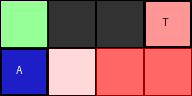

Top policy indices by E (final): [60 53 74 59 63 51 55 72]
60 [[2 0 0]
 [2 0 0]
 [0 0 0]] E_prob=0.0343 count=4.94
53 [[2 0 0]
 [0 0 0]
 [3 0 0]] E_prob=0.0296 count=4.26
74 [[2 0 0]
 [4 0 0]
 [4 0 0]] E_prob=0.0286 count=4.12
59 [[2 0 0]
 [1 0 0]
 [4 0 0]] E_prob=0.0200 count=2.88
63 [[2 0 0]
 [2 0 0]
 [3 0 0]] E_prob=0.0190 count=2.74
51 [[2 0 0]
 [0 0 0]
 [1 0 0]] E_prob=0.0178 count=2.57
55 [[2 0 0]
 [1 0 0]
 [0 0 0]] E_prob=0.0161 count=2.31
72 [[2 0 0]
 [4 0 0]
 [2 0 0]] E_prob=0.0120 count=1.72


In [31]:
# BLOCK 8: save gif and print top habit policies
gif_path = "defeat_arena_p3_c2.gif"
imageio.mimsave(gif_path, frames, fps=10)
print(f"Saved {gif_path}")
display(Image(gif_path))

# final normalized E
E_final = counts_to_probs(E_counts)
topk = 8
top_idx = np.argsort(E_final)[-topk:][::-1]
print("Top policy indices by E (final):", top_idx)
for i in top_idx:
    print(i, policies[i], f"E_prob={E_final[i]:.4f} count={E_counts[i]:.2f}")